# Exploratory Data Analysis (EDA)

## Overview
This notebook explores the cleaned Diabetes Hospital Readmission dataset. The goal is to understand the distribution of variables, examine class imbalance, identify important patterns, and study how features relate to the target variable `readmitted`.

The analysis focuses on:
- dataset structure and basic summary
- target variable distribution
- numerical feature distributions
- categorical feature distributions
- relationships between features and readmission
- correlation analysis for numeric variables

The insights from this notebook will guide the next stage of feature encoding and machine learning modeling.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/diabetes_clean_2.csv")

print(df.shape)
df.head()

(70422, 30)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,pioglitazone,rosiglitazone,insulin,glyburide-metformin,change,diabetesMed,readmitted,diag_1_grp,diag_2_grp,diag_3_grp
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,0,Diabetes,Other,Other
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,No,Up,No,Ch,Yes,0,Other,Diabetes,Other
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,Yes,0,Other,Diabetes,Other
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,No,Up,No,Ch,Yes,0,Other,Diabetes,Circulatory
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,No,Steady,No,Ch,Yes,0,Neoplasms,Neoplasms,Diabetes


In [13]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Shape: (70422, 30)

Data types:
object    18
int64     12
Name: count, dtype: int64

Missing values:
race                   0
gender                 0
diag_2_grp             0
diag_1_grp             0
readmitted             0
diabetesMed            0
change                 0
glyburide-metformin    0
insulin                0
rosiglitazone          0
dtype: int64


In [14]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Numeric columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numeric columns: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted']

Categorical columns: ['race', 'gender', 'age', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'diag_1_grp', 'diag_2_grp', 'diag_3_grp']


### Target variable

readmitted
0    64130
1     6292
Name: count, dtype: int64
readmitted
0    0.910653
1    0.089347
Name: proportion, dtype: float64


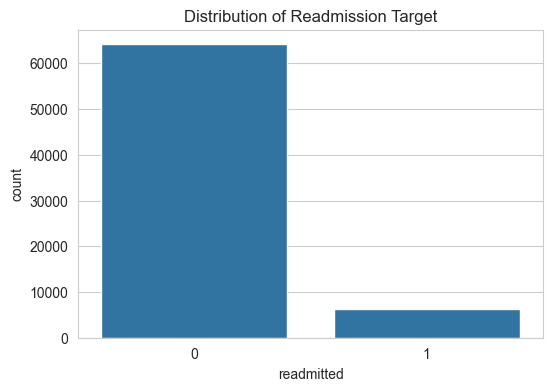

In [15]:
print(df["readmitted"].value_counts())
print(df["readmitted"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x="readmitted", data=df)
plt.title("Distribution of Readmission Target")
plt.show()

### Observation
The target variable is imbalanced, with many more patients in class 0 than class 1. This should be considered later during model training and evaluation.

In [16]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
admission_type_id,70422.0,2.104939,1.508879,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,70422.0,3.478274,5.226912,1.0,1.0,1.0,3.0,28.0
admission_source_id,70422.0,5.641220,4.165283,1.0,1.0,7.0,7.0,25.0
time_in_hospital,70422.0,4.283818,2.939820,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,70422.0,42.916333,19.903041,1.0,31.0,44.0,57.0,132.0
num_procedures,70422.0,1.422041,1.754859,0.0,0.0,1.0,2.0,6.0
num_medications,70422.0,15.667291,8.282978,1.0,10.0,14.0,20.0,81.0
number_outpatient,70422.0,0.280097,1.064739,0.0,0.0,0.0,0.0,42.0
number_emergency,70422.0,0.103874,0.511205,0.0,0.0,0.0,0.0,42.0
number_inpatient,70422.0,0.176891,0.603303,0.0,0.0,0.0,0.0,12.0


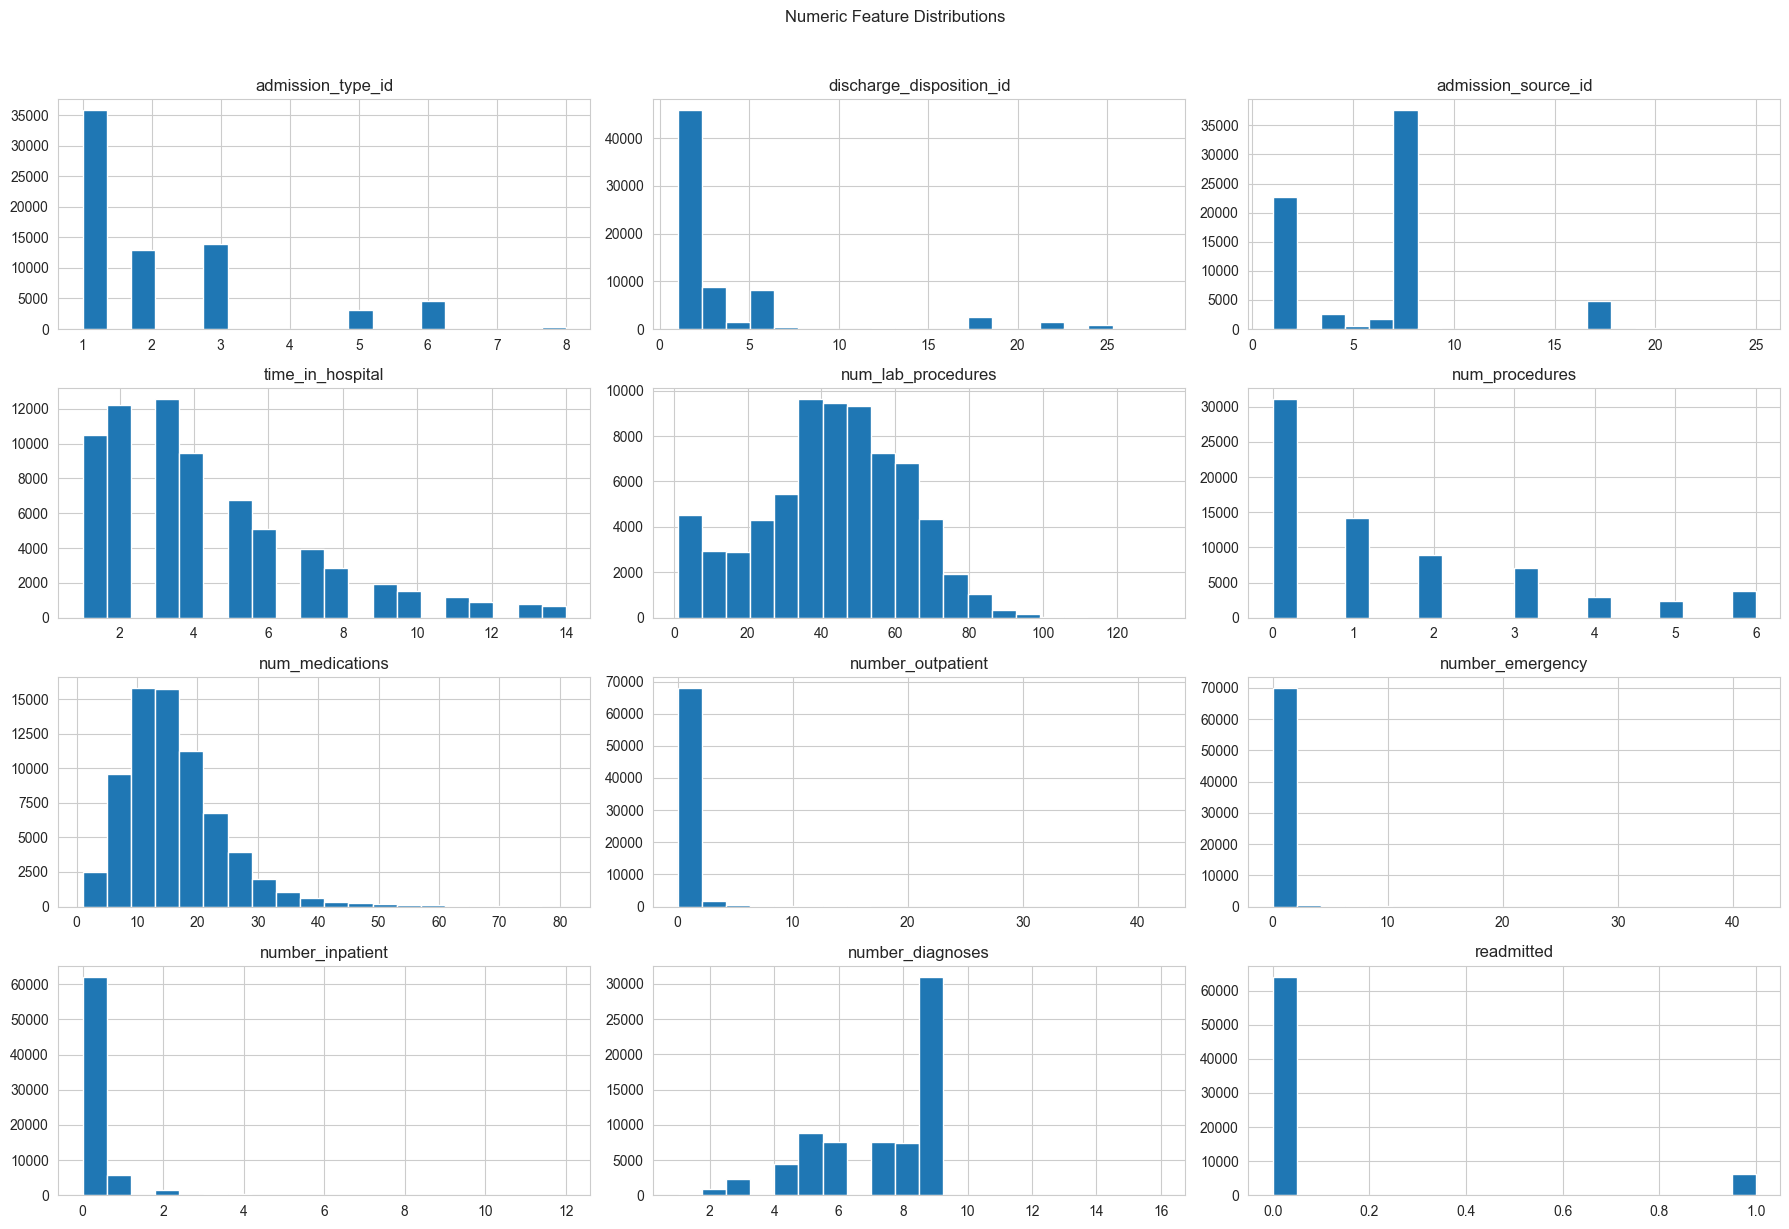

In [17]:
df[num_cols].hist(figsize=(18, 12), bins=20)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

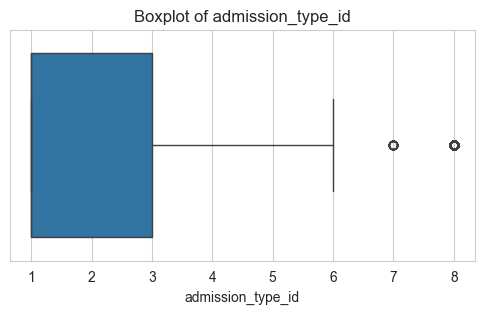

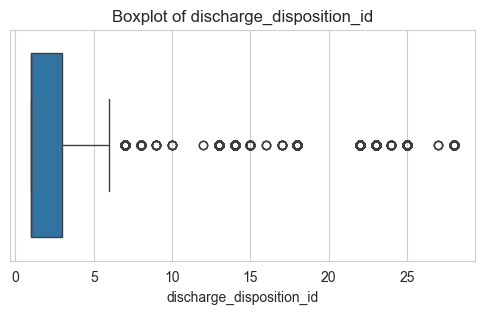

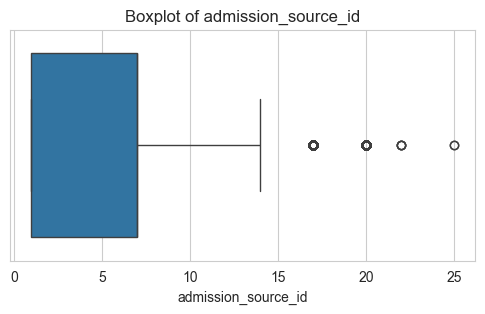

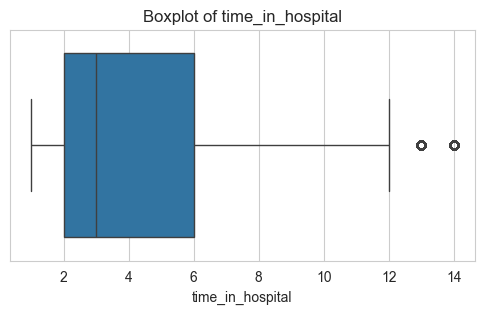

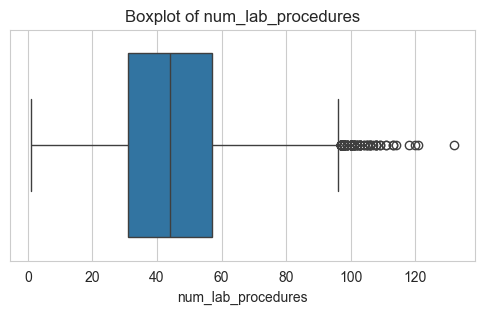

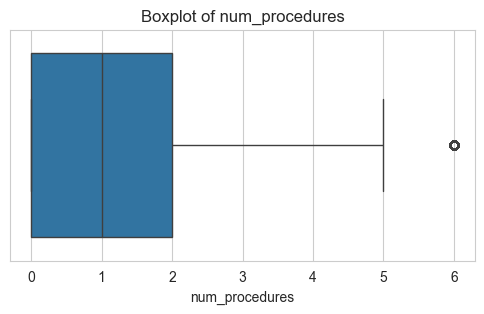

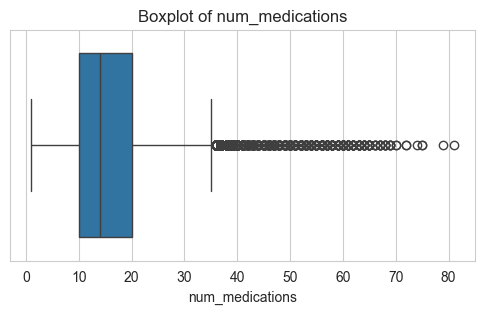

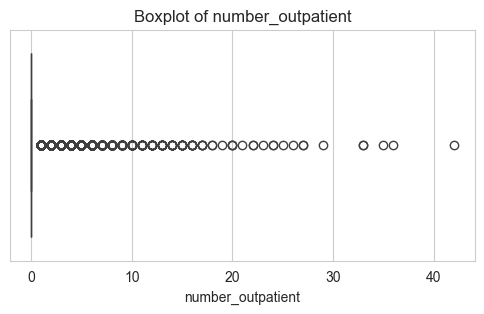

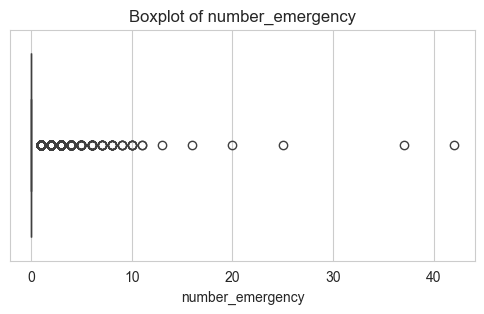

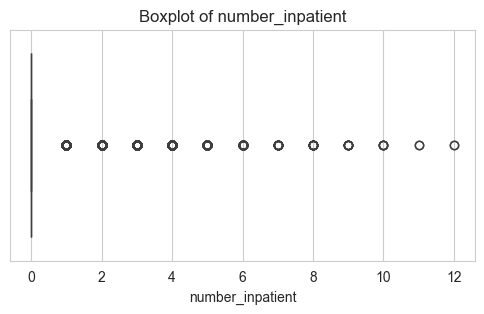

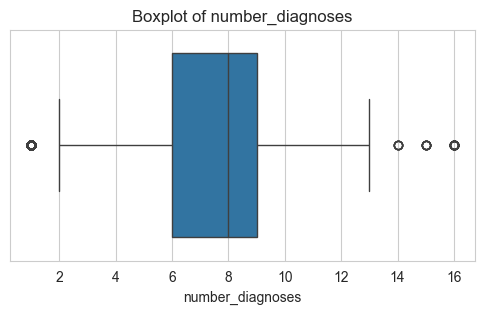

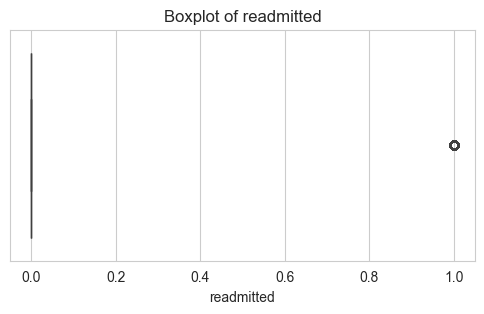

In [18]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

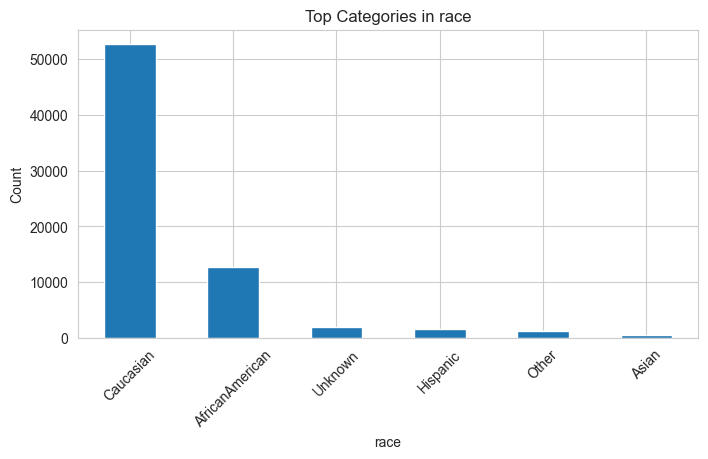

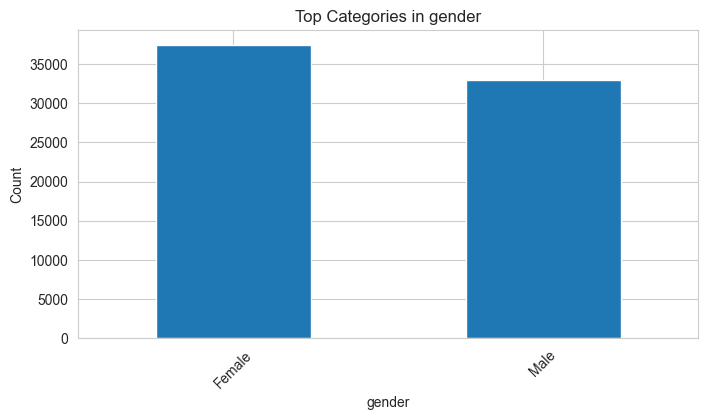

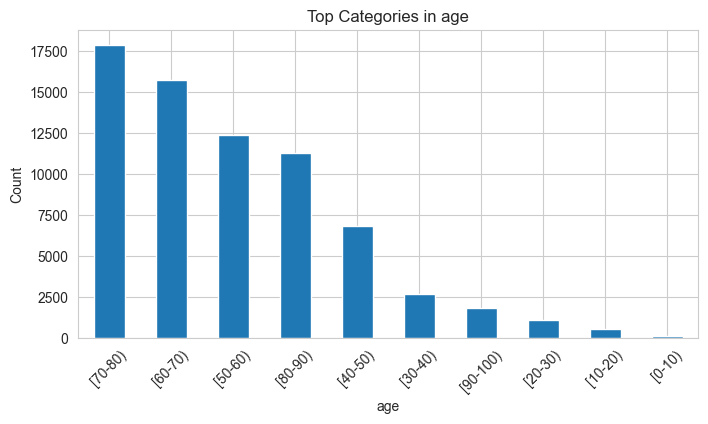

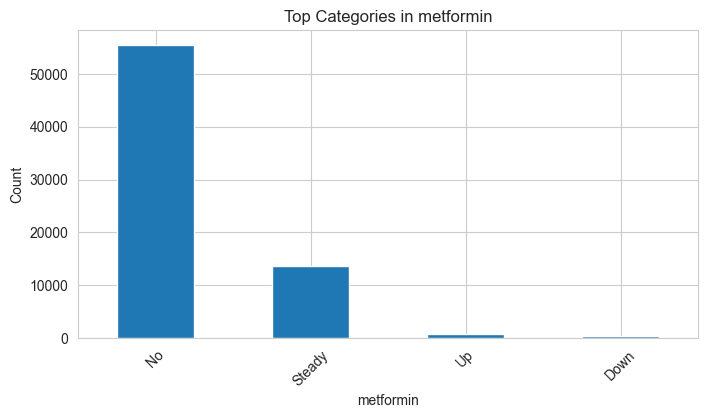

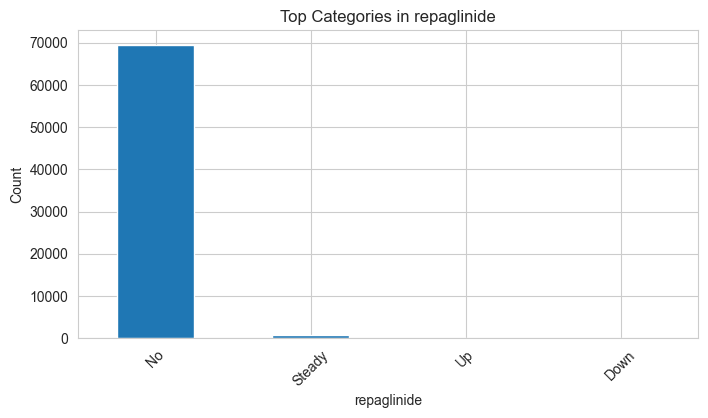

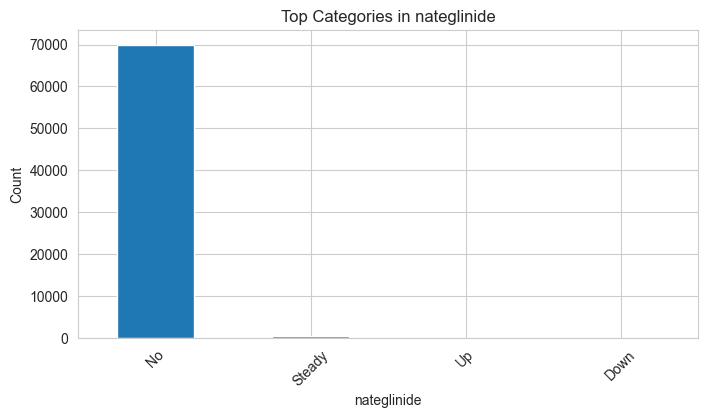

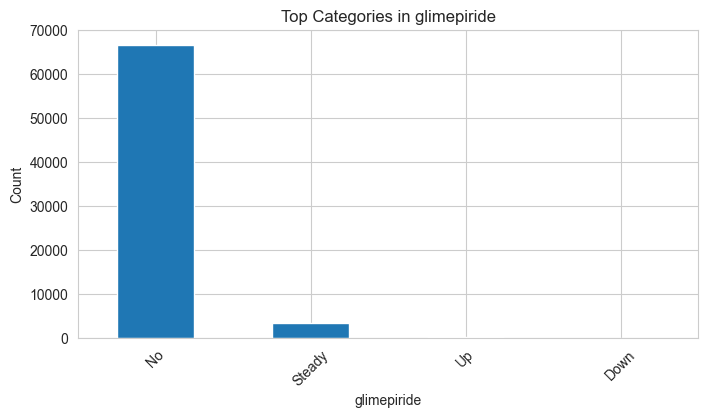

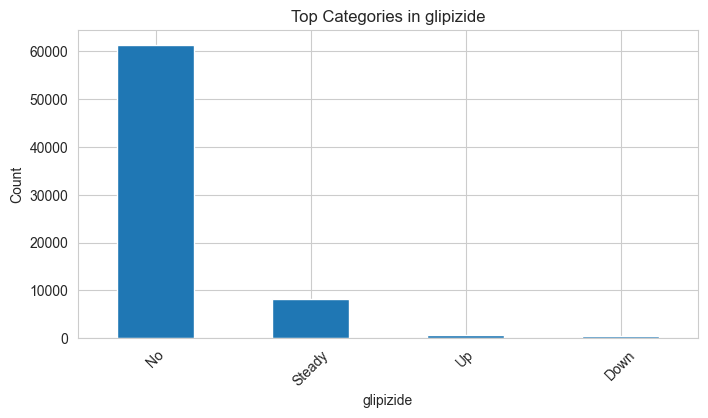

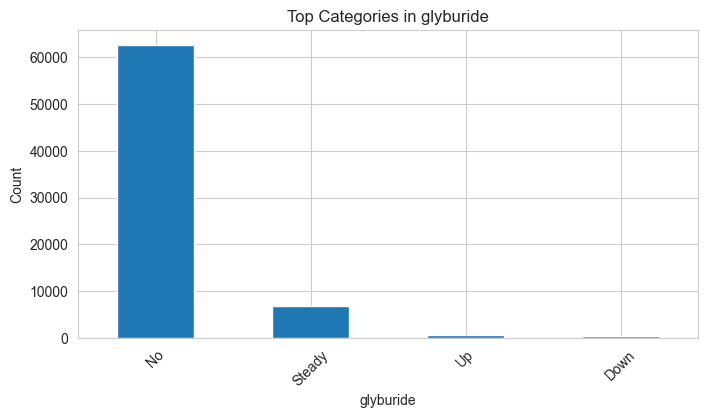

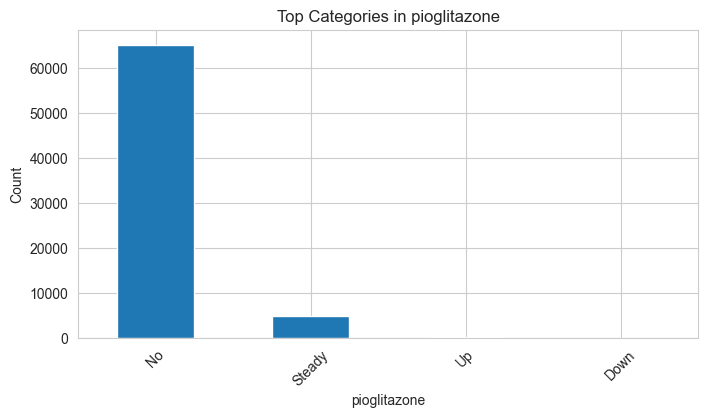

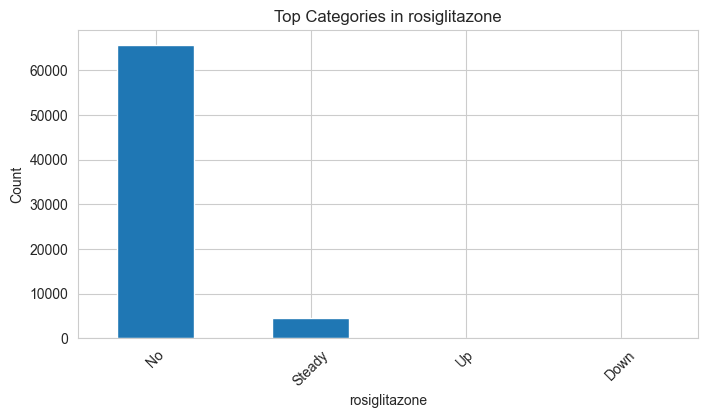

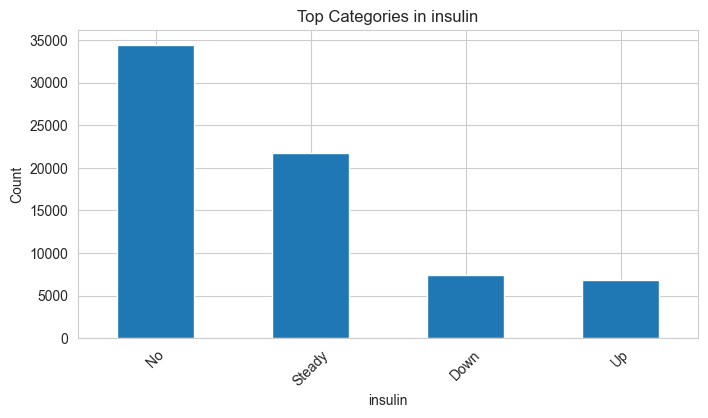

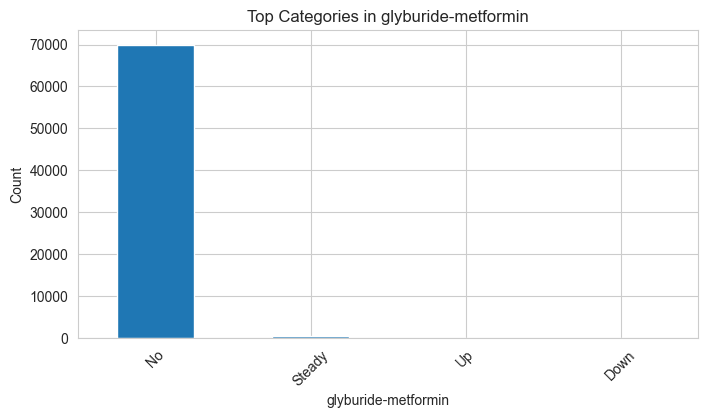

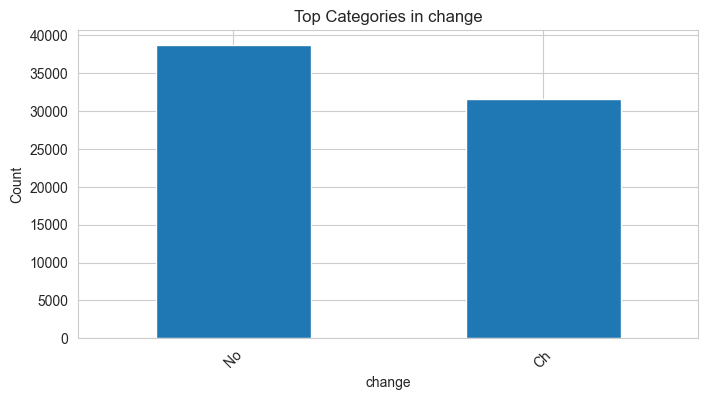

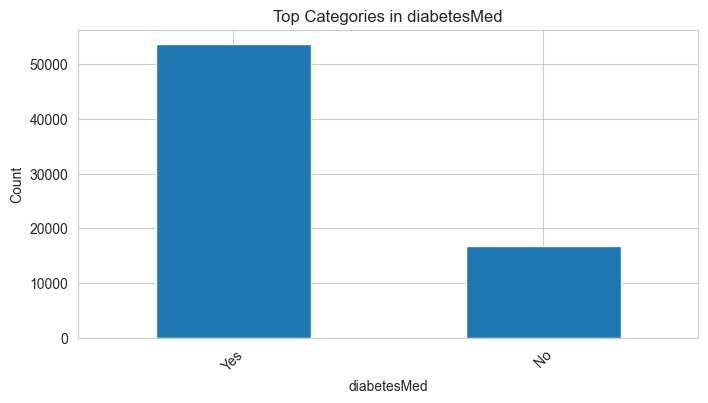

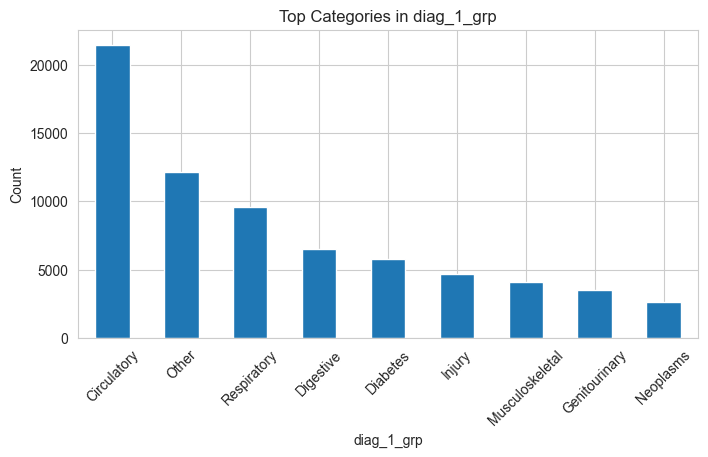

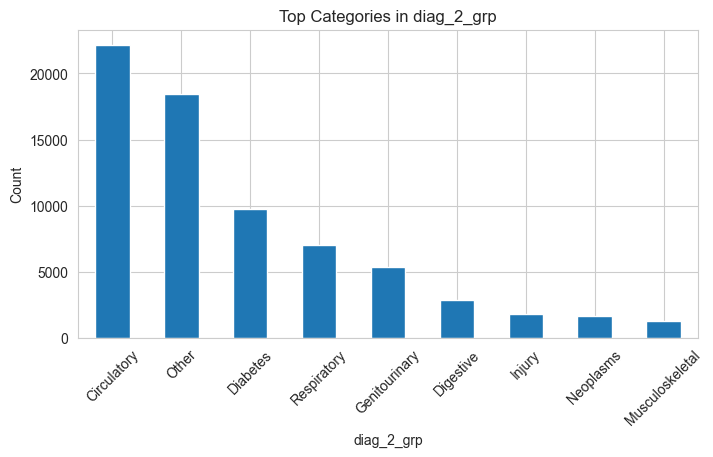

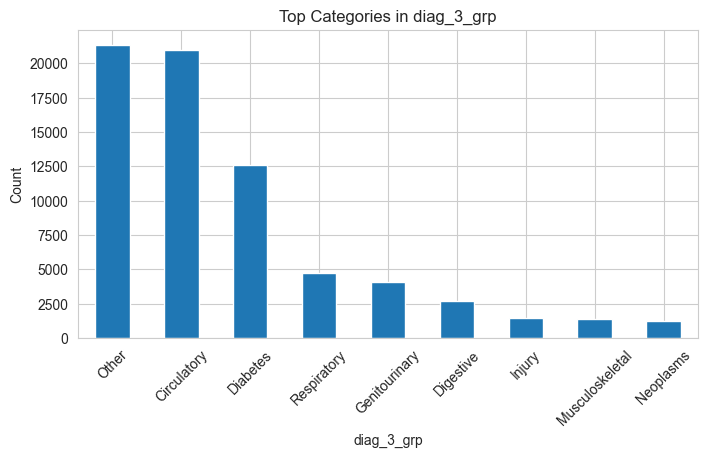

In [19]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top Categories in {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

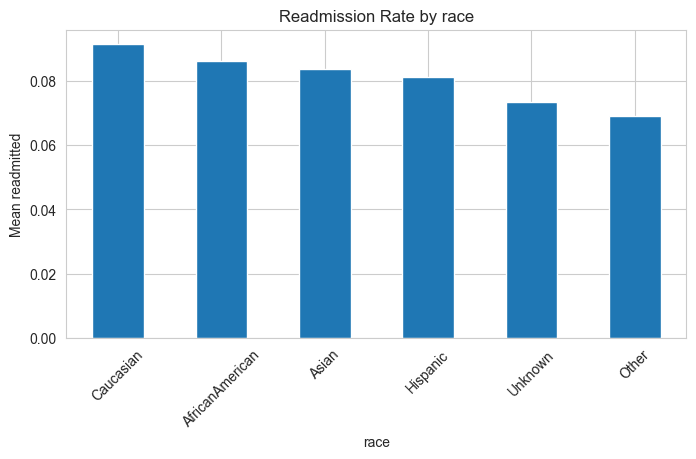

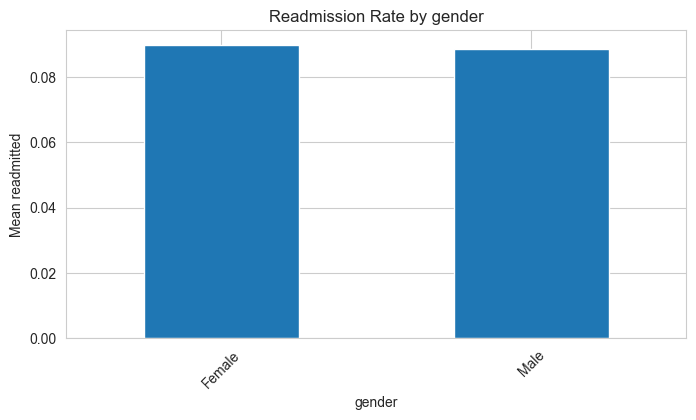

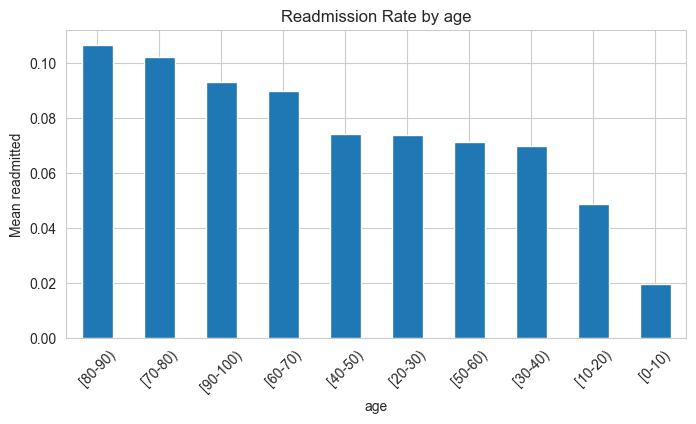

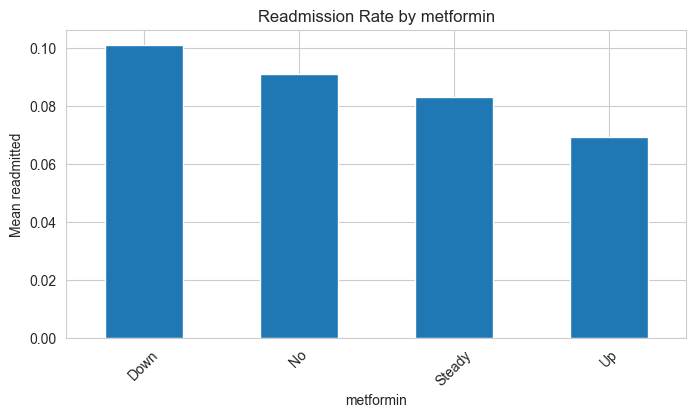

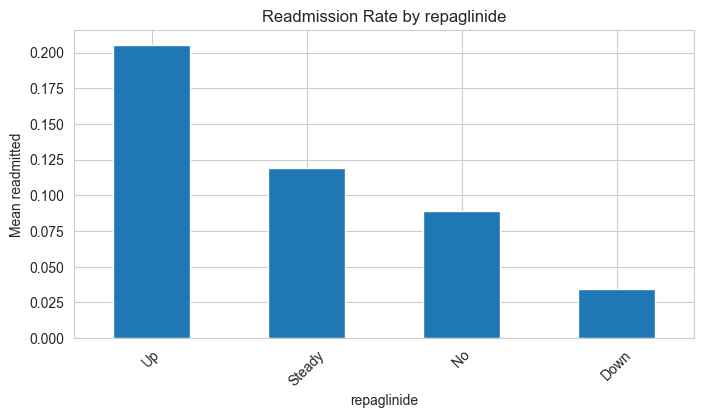

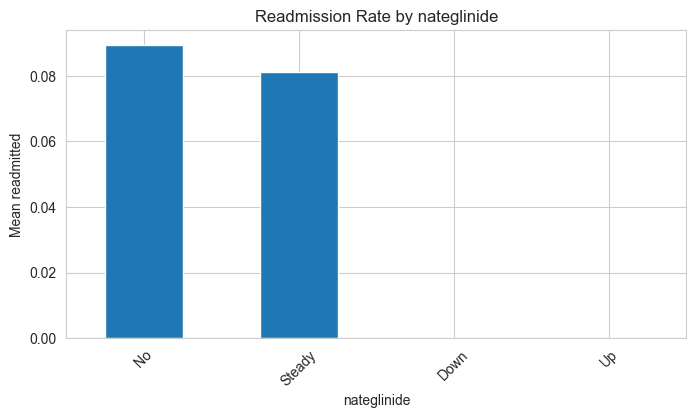

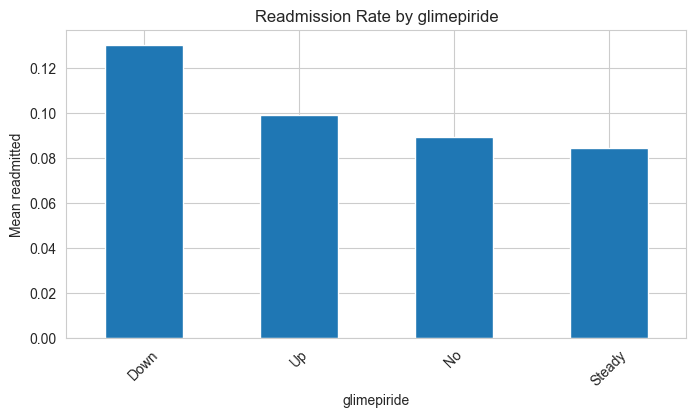

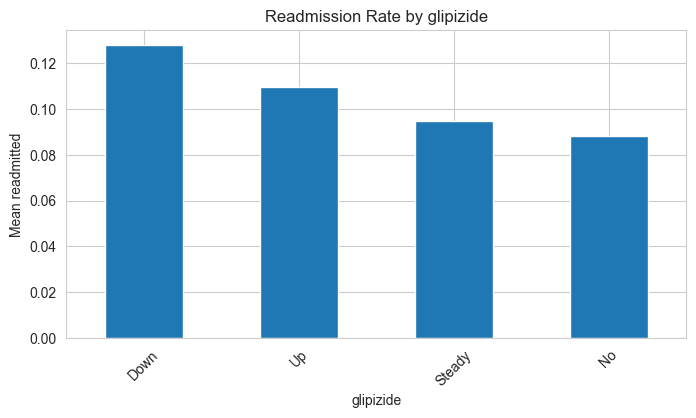

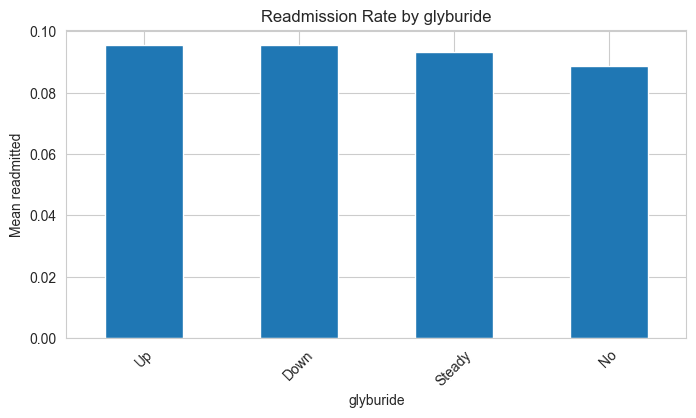

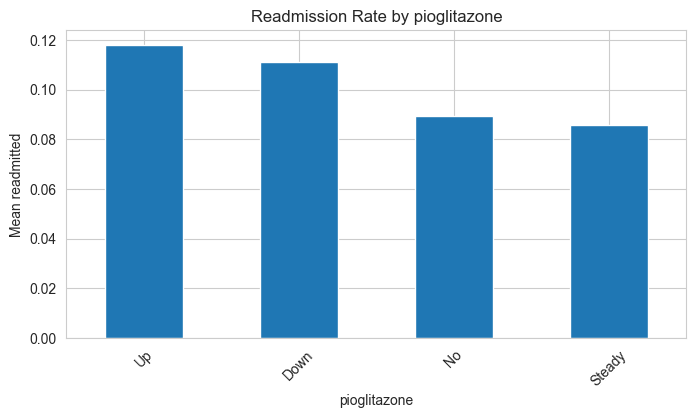

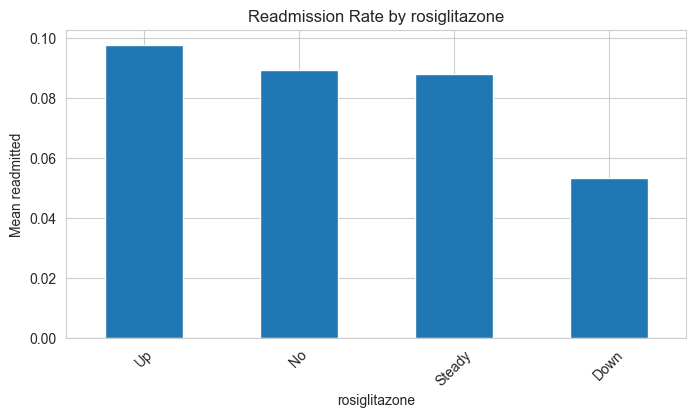

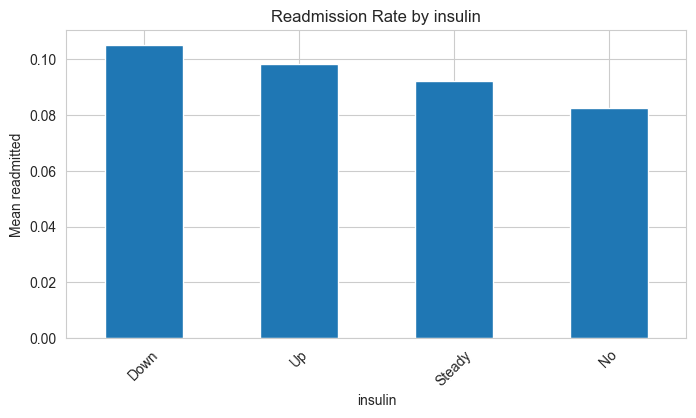

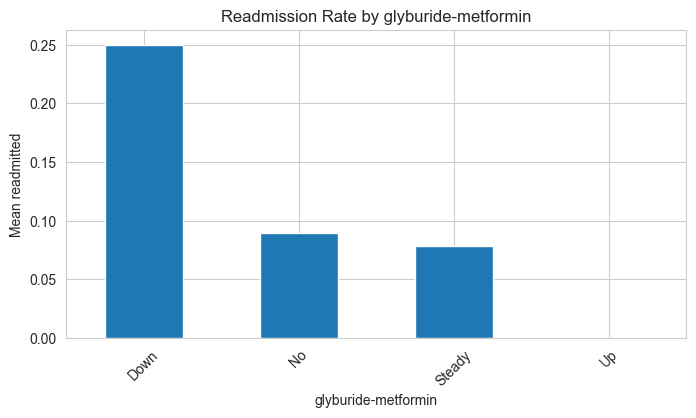

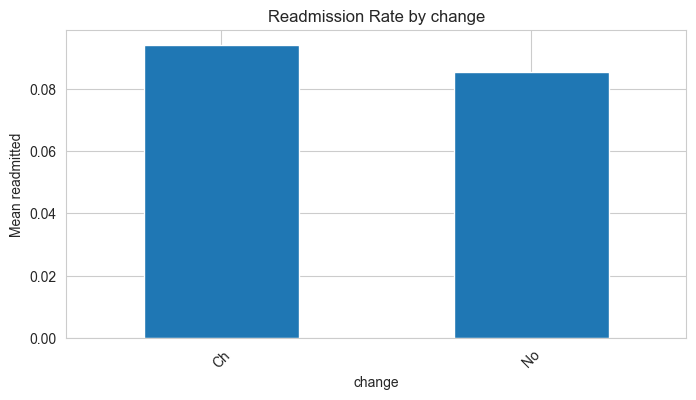

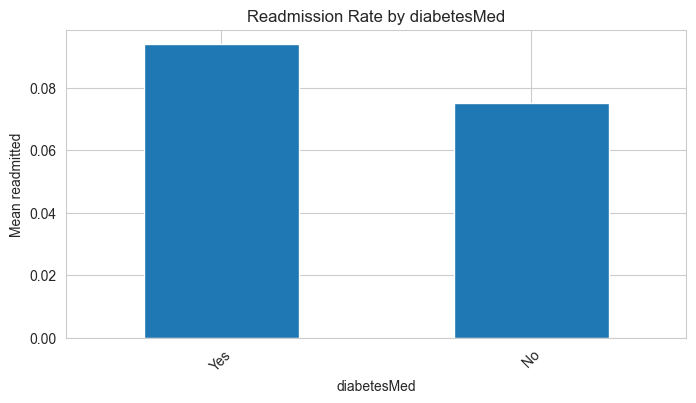

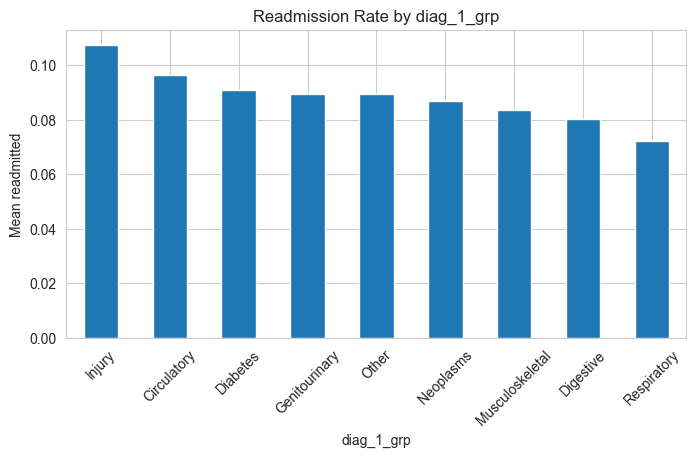

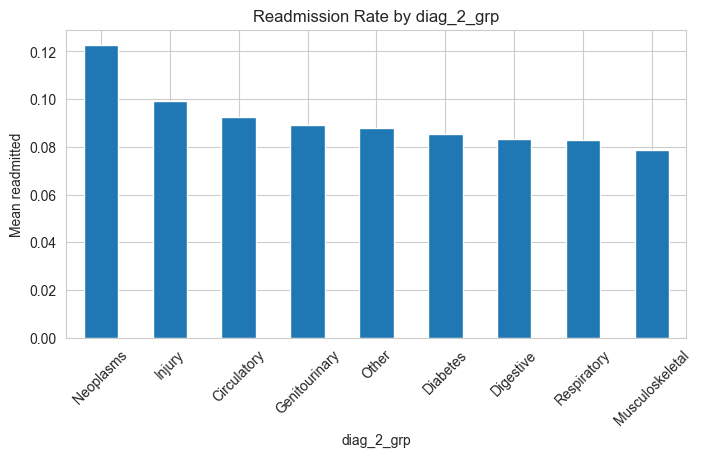

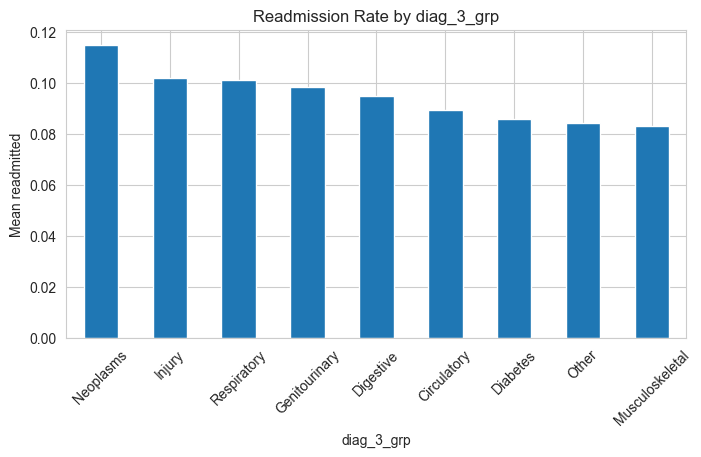

In [20]:
for col in cat_cols:
    rate = df.groupby(col)["readmitted"].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8,4))
    rate.head(10).plot(kind="bar")
    plt.title(f"Readmission Rate by {col}")
    plt.ylabel("Mean readmitted")
    plt.xticks(rotation=45)
    plt.show()

In [21]:
df.groupby("readmitted")[num_cols].mean().T

readmitted,0,1
admission_type_id,2.105723,2.096949
discharge_disposition_id,3.371168,4.569930
admission_source_id,5.634149,5.713287
time_in_hospital,4.233385,4.797839
num_lab_procedures,42.718650,44.931182
num_procedures,1.421955,1.422918
num_medications,15.573647,16.621742
number_outpatient,0.277171,0.309917
number_emergency,0.099361,0.149873
number_inpatient,0.157867,0.370788


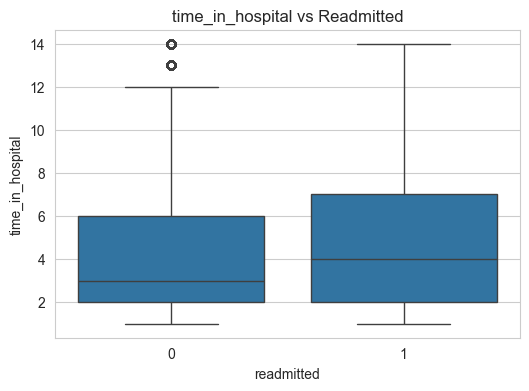

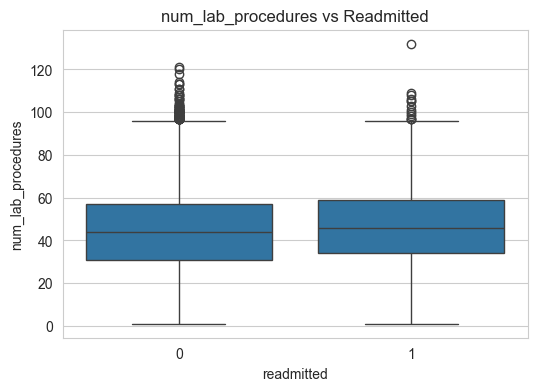

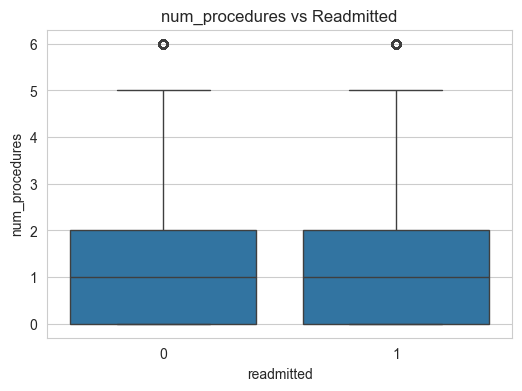

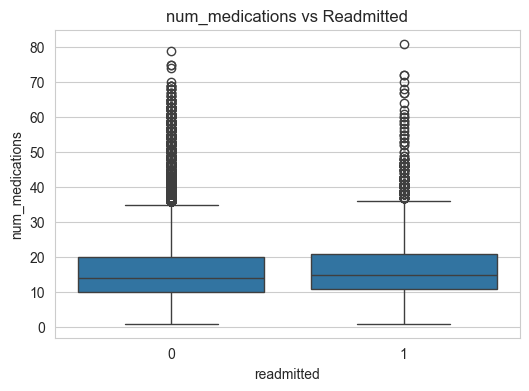

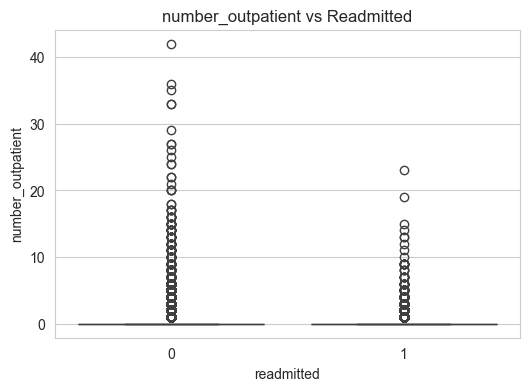

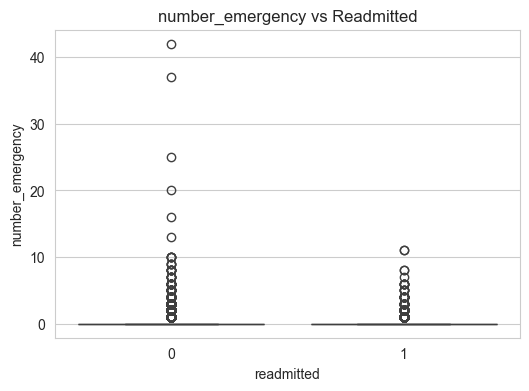

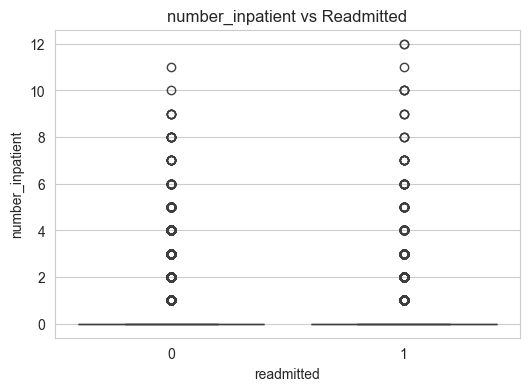

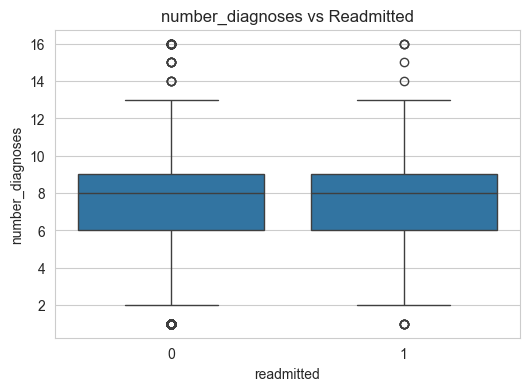

In [22]:
important_num = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

for col in important_num:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="readmitted", y=col, data=df)
    plt.title(f"{col} vs Readmitted")
    plt.show()

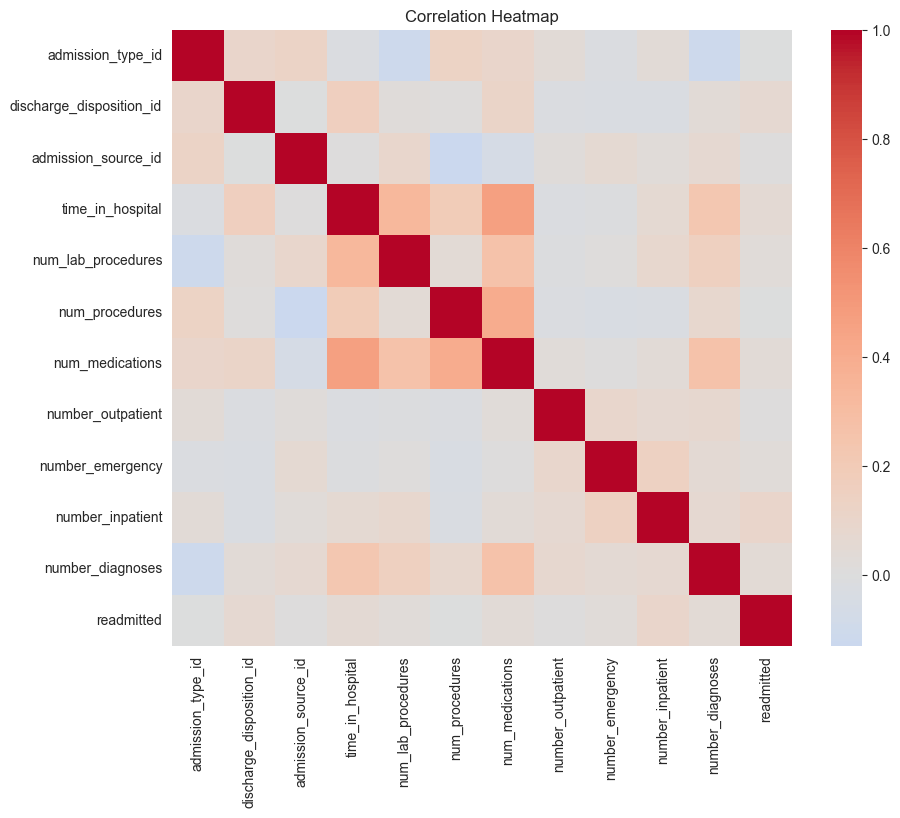

In [23]:
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
corr["readmitted"].sort_values(ascending=False)

readmitted                  1.000000
number_inpatient            0.100671
discharge_disposition_id    0.065420
time_in_hospital            0.054768
number_diagnoses            0.044213
num_medications             0.036094
num_lab_procedures          0.031710
number_emergency            0.028185
number_outpatient           0.008773
admission_source_id         0.005419
num_procedures              0.000156
admission_type_id          -0.001659
Name: readmitted, dtype: float64

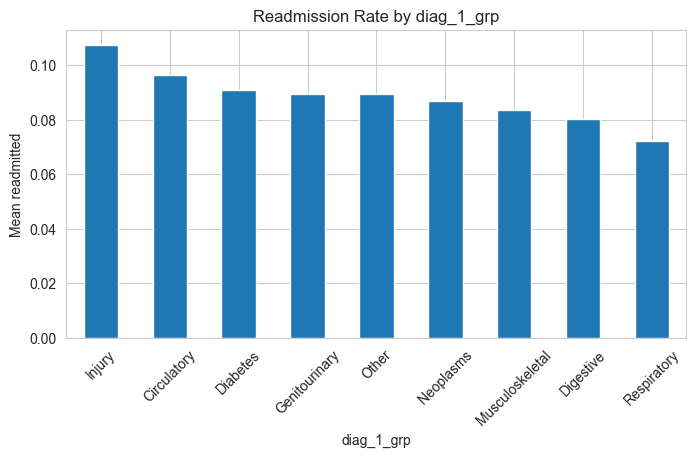

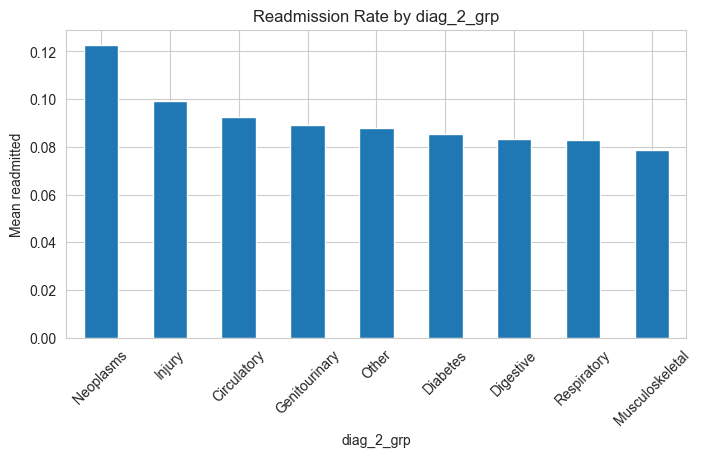

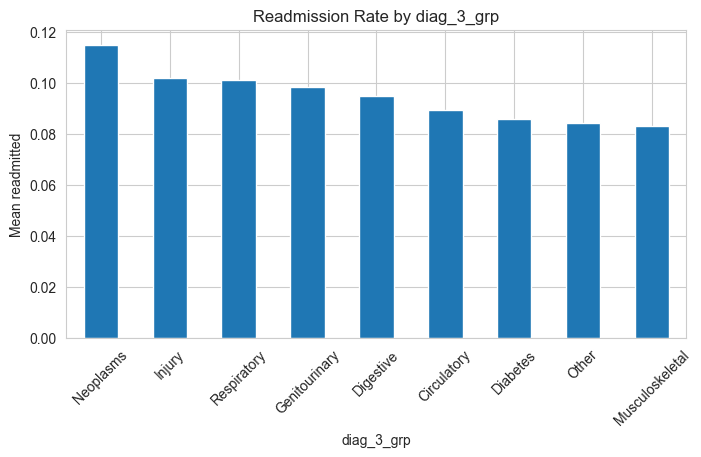

In [25]:
diag_cols = ["diag_1_grp", "diag_2_grp", "diag_3_grp"]

for col in diag_cols:
    rate = df.groupby(col)["readmitted"].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8,4))
    rate.plot(kind="bar")
    plt.title(f"Readmission Rate by {col}")
    plt.ylabel("Mean readmitted")
    plt.xticks(rotation=45)
    plt.show()

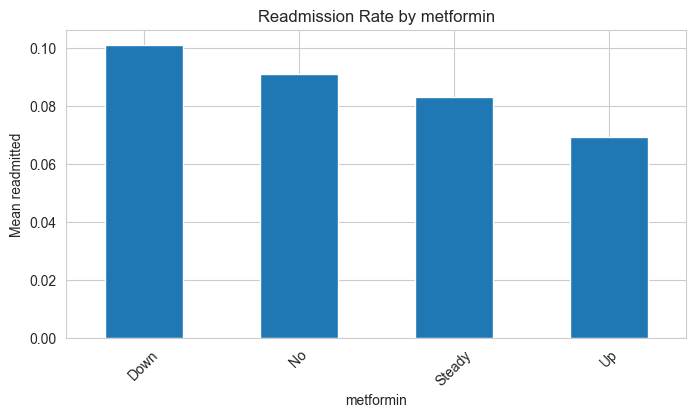

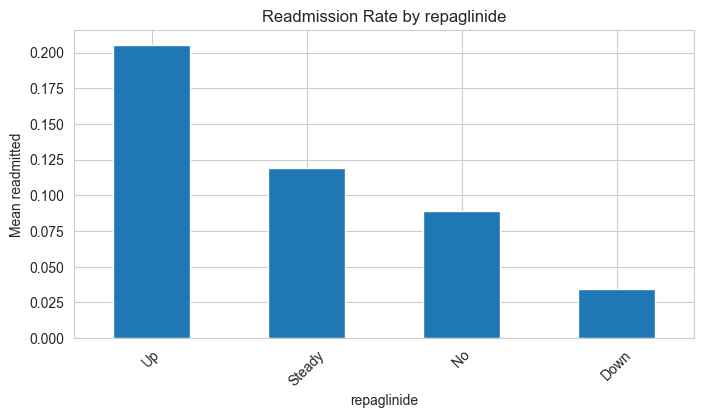

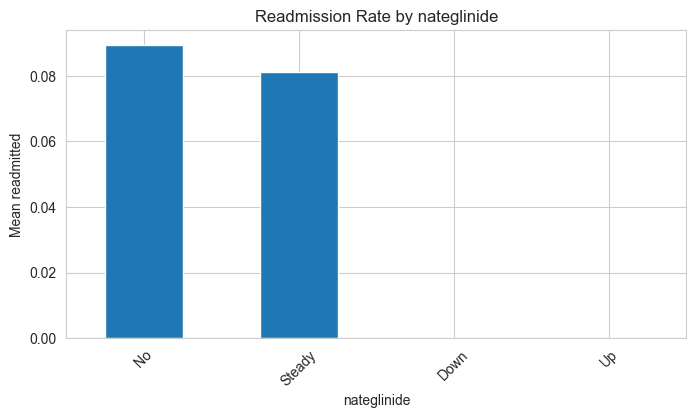

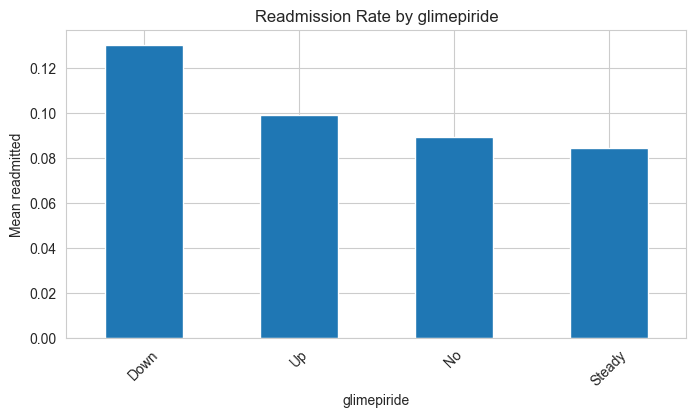

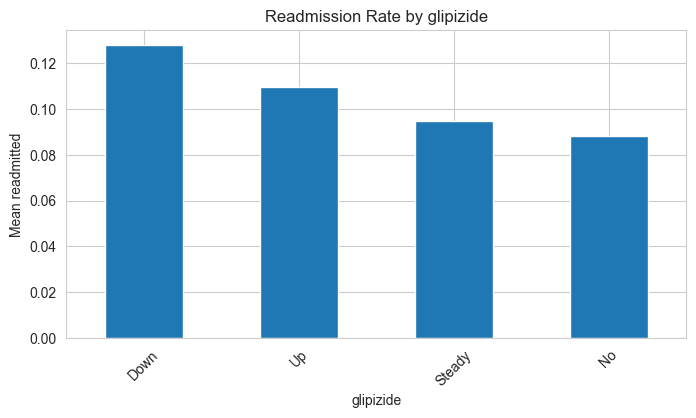

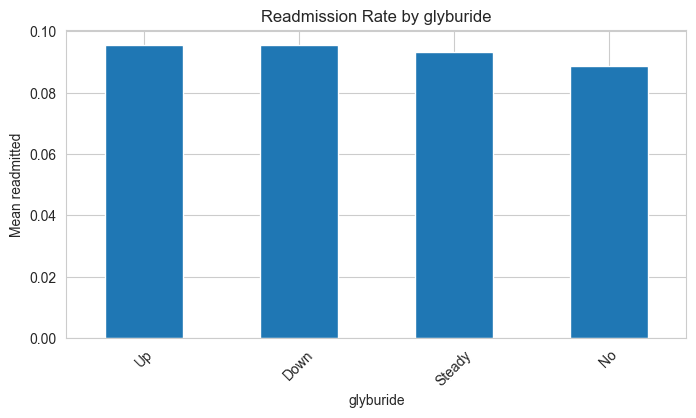

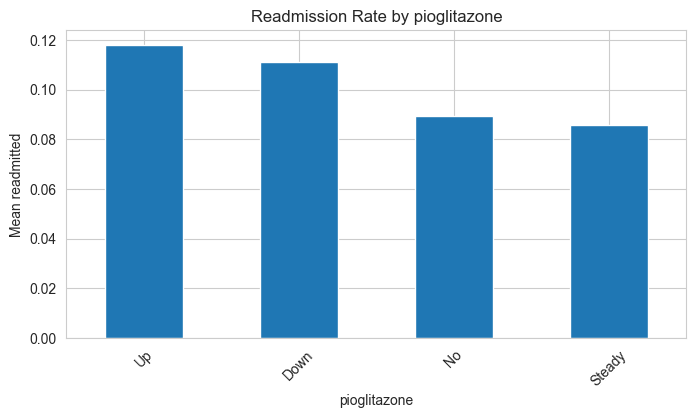

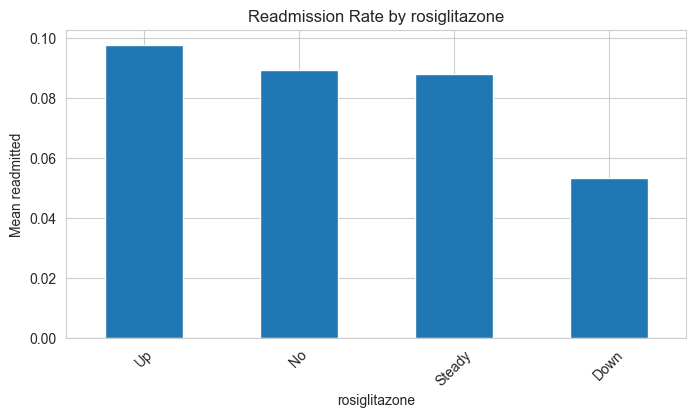

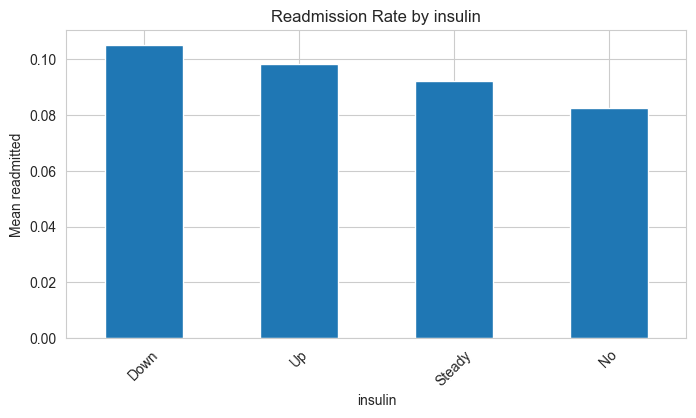

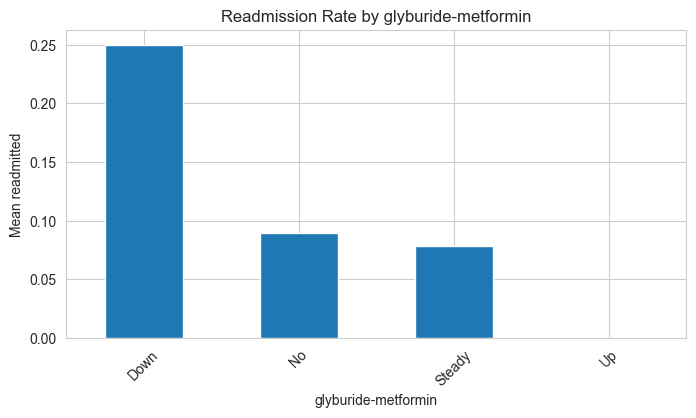

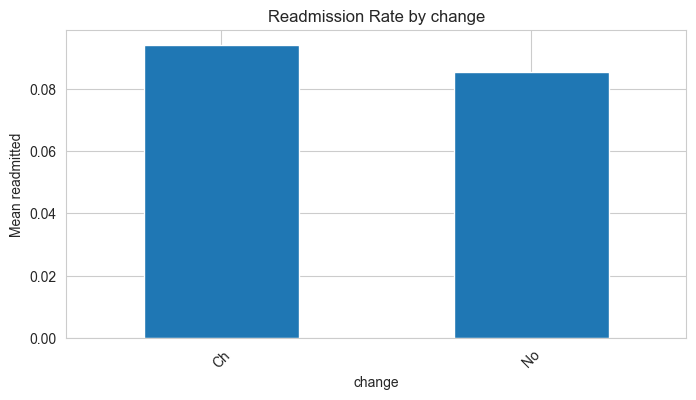

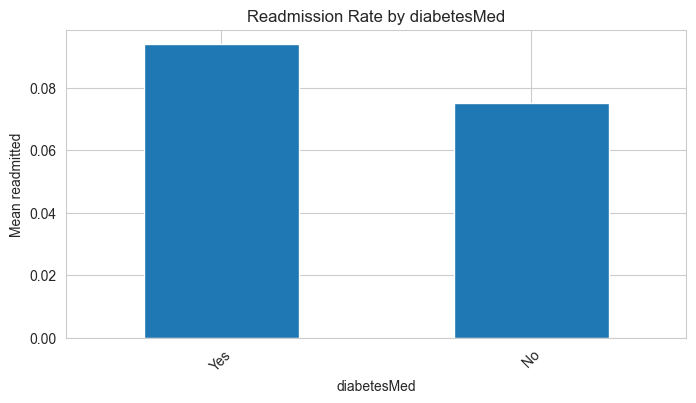

In [26]:
med_cols = [
    "metformin", "repaglinide", "nateglinide", "glimepiride",
    "glipizide", "glyburide", "pioglitazone", "rosiglitazone",
    "insulin", "glyburide-metformin", "change", "diabetesMed"
]

for col in med_cols:
    rate = df.groupby(col)["readmitted"].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8,4))
    rate.plot(kind="bar")
    plt.title(f"Readmission Rate by {col}")
    plt.ylabel("Mean readmitted")
    plt.xticks(rotation=45)
    plt.show()